# CNN Model Development and Evaluation

Purpose: Train and evaluate three CNN architectures (SimpleCNN, DeepCNN, StrongCNN) for binary brain MRI classification.

Outputs:
- experiments_summary.csv - Performance metrics for all models
- best_model.pth - Checkpoint of the best performing model
- test_predictions.csv - Predictions on test set with labels and probabilities

---

## 1. Imports and Configuration

In [1]:
import os
import random
import shutil
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

# sklearn metrics
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, auc
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Image size
IMG_SIZE = 224

Using device: cpu


---

## 2. Dataset Preparation

Load preprocessed dataset from dataset_processed/ folder with 70/15/15 split.

In [2]:
# Dataset paths (relative to parent directory since notebook is in cnn/ folder)
BASE = Path("../dataset_processed")
assert BASE.exists(), f"{BASE} does not exist. Run 2preprocessing.ipynb first."

train_dir = BASE / "train"
val_dir = BASE / "val"
test_dir = BASE / "test"

# Verify splits
print("="*60)
print("DATASET SUMMARY")
print("="*60)
for split_name, split_dir in [("Train", train_dir), ("Val", val_dir), ("Test", test_dir)]:
    no_count = len(list((split_dir/"no").glob("*")))
    yes_count = len(list((split_dir/"yes").glob("*")))
    print(f"{split_name:5s}: {no_count + yes_count:4d} images (no={no_count}, yes={yes_count})")
print("="*60)

DATASET SUMMARY
Train: 2100 images (no=1050, yes=1050)
Val  :  450 images (no=225, yes=225)
Test :  450 images (no=225, yes=225)


---

## 3. Calculate Dataset Statistics

Compute mean and standard deviation for normalization.

In [3]:
def compute_mean_std(folder, sample_size=500):
    """
    Compute channel-wise mean and std from a sample of images.
    
    Args:
        folder: Path to image folder
        sample_size: Number of images to sample
        
    Returns:
        mean, std as numpy arrays
    """
    files = list(Path(folder).rglob("*.jpg")) + list(Path(folder).rglob("*.png"))
    sampled = random.sample(files, min(sample_size, len(files)))
    
    pixels = []
    for f in sampled:
        img = np.array(Image.open(f).convert("RGB")) / 255.0  # Normalize to [0,1]
        pixels.append(img)
    
    pixels = np.stack(pixels, axis=0)  # (N, H, W, 3)
    mean = pixels.mean(axis=(0,1,2))
    std = pixels.std(axis=(0,1,2))
    
    return mean, std

# Compute from training set
print("Computing dataset statistics from training set...")
mean, std = compute_mean_std(train_dir, sample_size=500)
print(f"Mean: {mean}")
print(f"Std:  {std}")

Computing dataset statistics from training set...
Mean: [0.2756828  0.27582243 0.27608075]
Std:  [0.27515707 0.27523241 0.27539983]


---

## 4. Data Loaders

Create data loaders with and without augmentation.

In [4]:
# Transform without augmentation (for SimpleCNN, DeepCNN, and validation/test)
transform_basic = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Transform with augmentation (for StrongCNN training)
transform_augmented = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Create datasets
train_dataset_basic = datasets.ImageFolder(train_dir, transform=transform_basic)
train_dataset_augmented = datasets.ImageFolder(train_dir, transform=transform_augmented)
val_dataset = datasets.ImageFolder(val_dir, transform=transform_basic)
test_dataset = datasets.ImageFolder(test_dir, transform=transform_basic)

# Create data loaders
BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader_basic = DataLoader(train_dataset_basic, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
train_loader_augmented = DataLoader(train_dataset_augmented, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Class mapping
class_to_idx = train_dataset_basic.class_to_idx
print(f"Class to index mapping: {class_to_idx}")

Class to index mapping: {'no': 0, 'yes': 1}


---

## 5. Model Architectures

Define three CNN variants with increasing complexity.

In [5]:
class SimpleCNN(nn.Module):
    """
    Baseline CNN with 3 convolutional layers.
    Minimal regularization for baseline performance.
    """
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*(IMG_SIZE//8)*(IMG_SIZE//8), 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class DeepCNN(nn.Module):
    """
    Deeper CNN with 5 convolutional layers.
    Uses BatchNorm and AdaptiveAvgPool for regularization.
    """
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_block(x)
        x = self.classifier(x)
        return x


class StrongCNN(nn.Module):
    """
    Strongest CNN with 6 convolutional layers.
    Uses BatchNorm, AdaptiveAvgPool, and highest dropout for maximum regularization.
    Trained with data augmentation.
    """
    def __init__(self, num_classes=2):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.classifier(x)
        return x

print("Model architectures defined.")

Model architectures defined.


---

## 6. Training Utilities

Helper functions for training, evaluation, and checkpointing.

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Train model for one epoch.
    
    Returns:
        epoch_loss, epoch_accuracy
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    """
    Evaluate model on given data loader.
    
    Returns:
        epoch_loss, epoch_accuracy, roc_auc, labels, probabilities
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * imgs.size(0)
            probs = F.softmax(outputs, dim=1)[:, 1]  # Probability for class 1 (tumor)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    try:
        roc_auc = roc_auc_score(all_labels, all_probs)
    except Exception:
        roc_auc = float("nan")
    
    return epoch_loss, epoch_acc, roc_auc, np.array(all_labels), np.array(all_probs)


def plot_training_curves(history, title="Training"):
    """
    Plot training and validation loss/accuracy curves.
    """
    epochs = range(1, len(history["train_loss"]) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss
    ax1.plot(epochs, history["train_loss"], label="Train Loss", marker='o')
    ax1.plot(epochs, history["val_loss"], label="Val Loss", marker='s')
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"{title} - Loss")
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Accuracy
    ax2.plot(epochs, history["train_acc"], label="Train Accuracy", marker='o')
    ax2.plot(epochs, history["val_acc"], label="Val Accuracy", marker='s')
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{title} - Accuracy")
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("Training utilities defined.")

Training utilities defined.


---

## 7. Training Function

Main training loop with early stopping and checkpointing.

In [7]:
def train_model(model, train_loader, val_loader, num_epochs, lr, weight_decay, 
                model_name, use_scheduler=False, patience=7):
    """
    Train a model with early stopping.
    
    Args:
        model: PyTorch model
        train_loader: Training data loader
        val_loader: Validation data loader
        num_epochs: Maximum number of epochs
        lr: Learning rate
        weight_decay: L2 regularization weight
        model_name: Name for saving checkpoint
        use_scheduler: Whether to use ReduceLROnPlateau
        patience: Early stopping patience
        
    Returns:
        history: Training history dictionary
        best_checkpoint_path: Path to saved checkpoint
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    scheduler = None
    if use_scheduler:
        if "simple" in model_name.lower():
            scheduler_patience = 6
        else:
            scheduler_patience = 8
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=scheduler_patience
        )
    
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_auc": []}
    best_val_loss = float("inf")
    checkpoint_path = f"{model_name}_temp.pth"
    epochs_no_improve = 0
    
    print("="*70)
    print(f"Training {model_name}")
    print("="*70)
    
    for epoch in range(1, num_epochs + 1):
        start_time = time.time()
        
        # Train
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss, val_acc, val_auc, _, _ = evaluate(model, val_loader, criterion, device)
        
        # Record history
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_auc"].append(val_auc)
        
        elapsed = time.time() - start_time
        
        print(f"Epoch {epoch:2d}/{num_epochs} [{elapsed:.1f}s] - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val AUC: {val_auc:.4f}")
        
        # Learning rate scheduler
        if scheduler is not None:
            scheduler.step(val_loss)
        
        # Save best checkpoint
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optim_state": optimizer.state_dict(),
                "val_loss": val_loss,
                "val_acc": val_acc,
                "val_auc": val_auc
            }, checkpoint_path)
            print("  Checkpoint saved.")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        # Early stopping
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch} epochs (no improvement for {epochs_no_improve} epochs).")
            break
    
    print("="*70)
    print(f"Training complete. Best val loss: {best_val_loss:.4f}")
    print("="*70)
    
    return history, checkpoint_path

print("Training function defined.")

Training function defined.


---

## 8. Train All Models

Train SimpleCNN, DeepCNN, and StrongCNN with appropriate hyperparameters.



Starting training for SimpleCNN...

Training SimpleCNN
Epoch  1/25 [19.0s] - Train Loss: 0.5973, Train Acc: 0.7043 | Val Loss: 0.4392, Val Acc: 0.7889, Val AUC: 0.8790
  Checkpoint saved.
Epoch  2/25 [18.4s] - Train Loss: 0.3576, Train Acc: 0.8438 | Val Loss: 0.2100, Val Acc: 0.9156, Val AUC: 0.9756
  Checkpoint saved.
Epoch  3/25 [18.1s] - Train Loss: 0.1640, Train Acc: 0.9424 | Val Loss: 0.1891, Val Acc: 0.9067, Val AUC: 0.9926
  Checkpoint saved.
Epoch  4/25 [18.1s] - Train Loss: 0.1012, Train Acc: 0.9652 | Val Loss: 0.1331, Val Acc: 0.9467, Val AUC: 0.9933
  Checkpoint saved.
Epoch  5/25 [18.2s] - Train Loss: 0.0410, Train Acc: 0.9867 | Val Loss: 0.0925, Val Acc: 0.9733, Val AUC: 0.9944
  Checkpoint saved.
Epoch  6/25 [18.2s] - Train Loss: 0.0225, Train Acc: 0.9952 | Val Loss: 0.0910, Val Acc: 0.9733, Val AUC: 0.9967
  Checkpoint saved.
Epoch  7/25 [18.3s] - Train Loss: 0.0099, Train Acc: 0.9962 | Val Loss: 0.1546, Val Acc: 0.9578, Val AUC: 0.9919
Epoch  8/25 [18.2s] - Train Loss

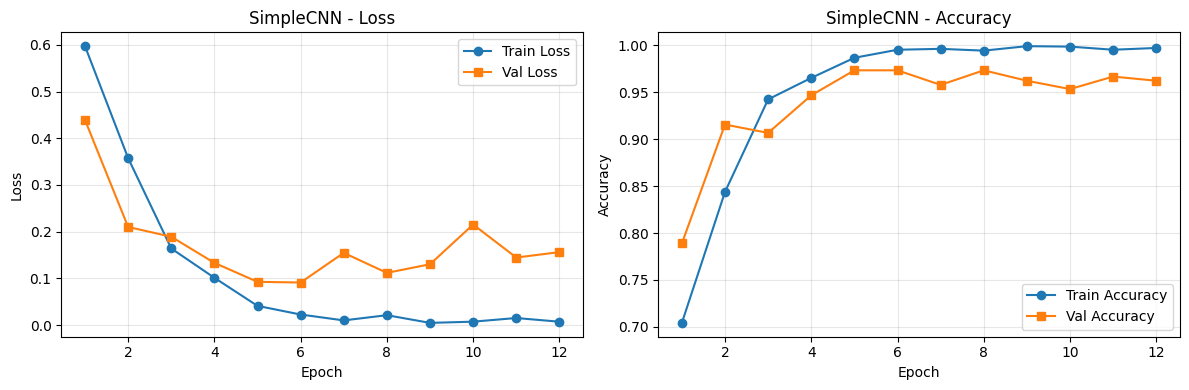



Starting training for DeepCNN...

Training DeepCNN
Epoch  1/30 [70.4s] - Train Loss: 0.5722, Train Acc: 0.7143 | Val Loss: 0.5251, Val Acc: 0.7467, Val AUC: 0.8216
  Checkpoint saved.
Epoch  2/30 [74.1s] - Train Loss: 0.5059, Train Acc: 0.7671 | Val Loss: 0.5840, Val Acc: 0.7333, Val AUC: 0.8647
Epoch  3/30 [75.0s] - Train Loss: 0.4520, Train Acc: 0.8038 | Val Loss: 0.4390, Val Acc: 0.7889, Val AUC: 0.8808
  Checkpoint saved.
Epoch  4/30 [74.8s] - Train Loss: 0.4366, Train Acc: 0.8057 | Val Loss: 0.8112, Val Acc: 0.6844, Val AUC: 0.8488
Epoch  5/30 [74.1s] - Train Loss: 0.4301, Train Acc: 0.8090 | Val Loss: 0.4914, Val Acc: 0.7778, Val AUC: 0.8678
Epoch  6/30 [74.0s] - Train Loss: 0.3983, Train Acc: 0.8290 | Val Loss: 0.4062, Val Acc: 0.8133, Val AUC: 0.9045
  Checkpoint saved.
Epoch  7/30 [74.3s] - Train Loss: 0.3984, Train Acc: 0.8319 | Val Loss: 0.5298, Val Acc: 0.7511, Val AUC: 0.8983
Epoch  8/30 [74.6s] - Train Loss: 0.3583, Train Acc: 0.8424 | Val Loss: 0.5062, Val Acc: 0.7778,

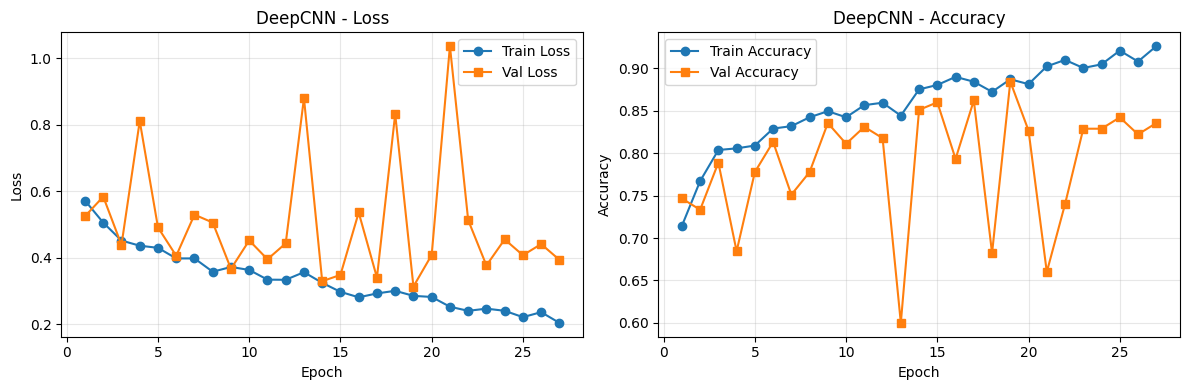



Starting training for StrongCNN...

Training StrongCNN
Epoch  1/40 [82.0s] - Train Loss: 0.5894, Train Acc: 0.7029 | Val Loss: 0.5224, Val Acc: 0.7378, Val AUC: 0.8209
  Checkpoint saved.
Epoch  2/40 [82.2s] - Train Loss: 0.5152, Train Acc: 0.7605 | Val Loss: 0.7410, Val Acc: 0.6222, Val AUC: 0.8453
Epoch  3/40 [78.8s] - Train Loss: 0.4984, Train Acc: 0.7700 | Val Loss: 0.7753, Val Acc: 0.6733, Val AUC: 0.8331
Epoch  4/40 [78.5s] - Train Loss: 0.4939, Train Acc: 0.7781 | Val Loss: 0.6659, Val Acc: 0.6889, Val AUC: 0.8775
Epoch  5/40 [78.2s] - Train Loss: 0.4583, Train Acc: 0.7986 | Val Loss: 0.4457, Val Acc: 0.7956, Val AUC: 0.8754
  Checkpoint saved.
Epoch  6/40 [84.7s] - Train Loss: 0.4741, Train Acc: 0.7910 | Val Loss: 0.4693, Val Acc: 0.7711, Val AUC: 0.8990
Epoch  7/40 [86.4s] - Train Loss: 0.4486, Train Acc: 0.8024 | Val Loss: 0.4535, Val Acc: 0.8111, Val AUC: 0.8920
Epoch  8/40 [79.6s] - Train Loss: 0.4186, Train Acc: 0.8195 | Val Loss: 0.5121, Val Acc: 0.7844, Val AUC: 0.8780

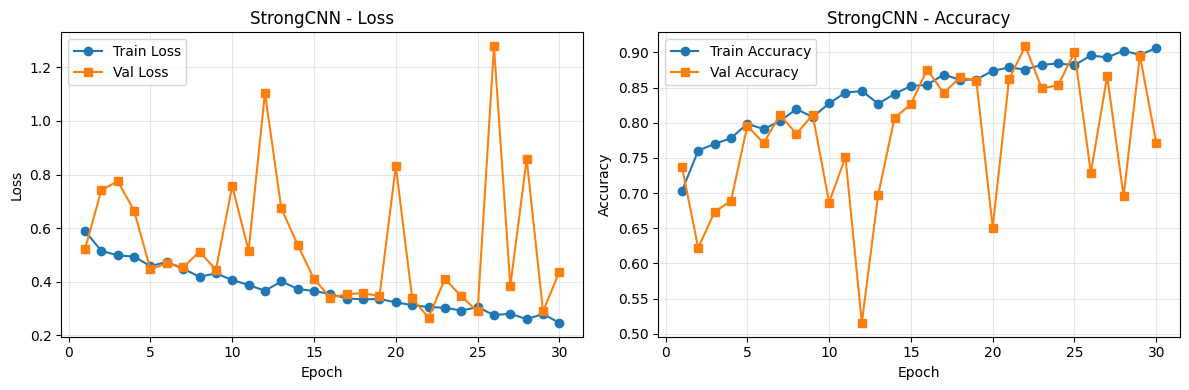



All models trained successfully.


In [8]:
# Training configurations
models_config = [
    {
        "name": "SimpleCNN",
        "model": SimpleCNN(num_classes=2),
        "train_loader": train_loader_basic,
        "epochs": 25,
        "lr": 1e-3,
        "use_scheduler": False,
        "patience": 6
    },
    {
        "name": "DeepCNN",
        "model": DeepCNN(num_classes=2),
        "train_loader": train_loader_basic,
        "epochs": 30,
        "lr": 5e-4,
        "use_scheduler": True,
        "patience": 8
    },
    {
        "name": "StrongCNN",
        "model": StrongCNN(num_classes=2),
        "train_loader": train_loader_augmented,  # Uses augmentation
        "epochs": 40,
        "lr": 5e-4,
        "use_scheduler": True,
        "patience": 8
    }
]

# Train all models
training_results = []

for config in models_config:
    print(f"\n\nStarting training for {config['name']}...\n")
    
    history, checkpoint_path = train_model(
        model=config["model"],
        train_loader=config["train_loader"],
        val_loader=val_loader,
        num_epochs=config["epochs"],
        lr=config["lr"],
        weight_decay=1e-4,
        model_name=config["name"],
        use_scheduler=config["use_scheduler"],
        patience=config["patience"]
    )
    
    # Plot training curves
    plot_training_curves(history, title=config["name"])
    
    training_results.append({
        "name": config["name"],
        "model_class": config["model"].__class__,
        "checkpoint": checkpoint_path,
        "history": history
    })

print("\n\nAll models trained successfully.")

---

## 9. Test Evaluation

Evaluate all models on test set and determine the best model.

TEST RESULTS: SimpleCNN
Test Loss:     0.0414
Test Accuracy: 0.9844
Test AUC:      0.9993

Classification Report:
              precision    recall  f1-score   support

          no     0.9781    0.9911    0.9845       225
         yes     0.9910    0.9778    0.9843       225

    accuracy                         0.9844       450
   macro avg     0.9845    0.9844    0.9844       450
weighted avg     0.9845    0.9844    0.9844       450


Confusion Matrix:
[[223   2]
 [  5 220]]


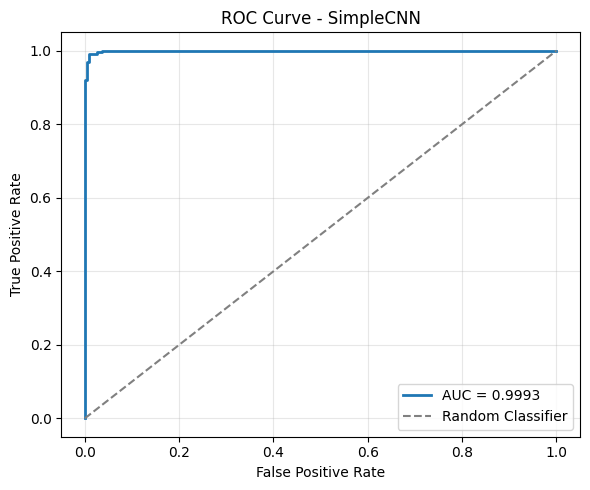

TEST RESULTS: DeepCNN
Test Loss:     0.2852
Test Accuracy: 0.8978
Test AUC:      0.9588

Classification Report:
              precision    recall  f1-score   support

          no     0.9409    0.8489    0.8925       225
         yes     0.8623    0.9467    0.9025       225

    accuracy                         0.8978       450
   macro avg     0.9016    0.8978    0.8975       450
weighted avg     0.9016    0.8978    0.8975       450


Confusion Matrix:
[[191  34]
 [ 12 213]]


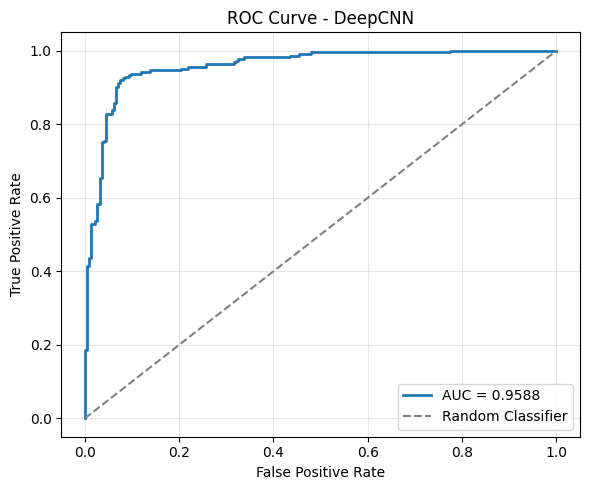

TEST RESULTS: StrongCNN
Test Loss:     0.2509
Test Accuracy: 0.9200
Test AUC:      0.9639

Classification Report:
              precision    recall  f1-score   support

          no     0.9200    0.9200    0.9200       225
         yes     0.9200    0.9200    0.9200       225

    accuracy                         0.9200       450
   macro avg     0.9200    0.9200    0.9200       450
weighted avg     0.9200    0.9200    0.9200       450


Confusion Matrix:
[[207  18]
 [ 18 207]]


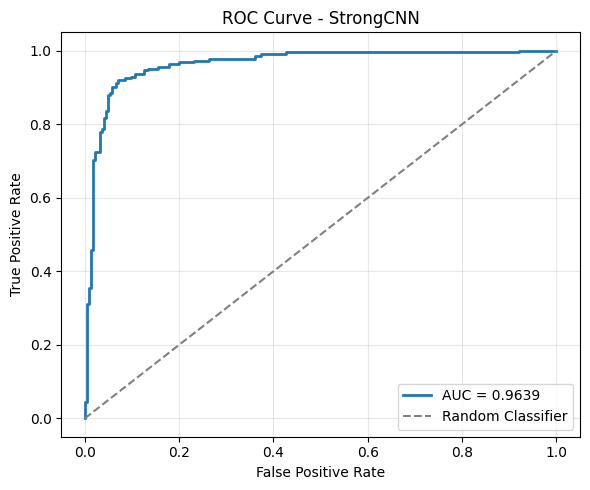


All models evaluated on test set.


In [9]:
def evaluate_on_test(checkpoint_path, model, test_loader, model_name):
    """
    Load checkpoint and evaluate on test set.
    
    Returns:
        Dictionary with test metrics
    """
    # Load checkpoint
    state = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state["model_state"])
    model.to(device)
    model.eval()
    
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, test_auc, labels, probs = evaluate(model, test_loader, criterion, device)
    
    # Classification report
    preds = (probs >= 0.5).astype(int)
    clf_report = classification_report(labels, preds, target_names=["no", "yes"], digits=4)
    cm = confusion_matrix(labels, preds)
    
    # ROC curve
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc_value = auc(fpr, tpr)
    
    print("="*70)
    print(f"TEST RESULTS: {model_name}")
    print("="*70)
    print(f"Test Loss:     {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test AUC:      {test_auc:.4f}")
    print("\nClassification Report:")
    print(clf_report)
    print("\nConfusion Matrix:")
    print(cm)
    print("="*70)
    
    # Plot ROC curve
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_value:.4f}", linewidth=2)
    plt.plot([0, 1], [0, 1], "--", color="gray", label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return {
        "model": model_name,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_auc": test_auc,
        "confusion_matrix": cm,
        "classification_report": clf_report,
        "labels": labels,
        "probabilities": probs
    }


# Evaluate all models on test set
test_results = []

for result in training_results:
    model_instance = result["model_class"](num_classes=2)
    
    test_metrics = evaluate_on_test(
        checkpoint_path=result["checkpoint"],
        model=model_instance,
        test_loader=test_loader,
        model_name=result["name"]
    )
    
    test_results.append({
        "name": result["name"],
        "checkpoint": result["checkpoint"],
        "model_class": result["model_class"],
        "metrics": test_metrics
    })

print("\nAll models evaluated on test set.")

---

## 10. Select Best Model

Determine the best model based on test AUC and save results.

In [10]:
# Create summary dataframe
summary_data = []
for result in test_results:
    summary_data.append({
        "model": result["name"],
        "test_loss": result["metrics"]["test_loss"],
        "test_acc": result["metrics"]["test_acc"],
        "test_auc": result["metrics"]["test_auc"]
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values("test_auc", ascending=False).reset_index(drop=True)

print("\n")
print("="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)
print(summary_df.to_string(index=False))
print("="*70)

# Select best model based on test AUC
best_model_name = summary_df.iloc[0]["model"]
best_model_auc = summary_df.iloc[0]["test_auc"]

print(f"\nBest Model: {best_model_name} (Test AUC: {best_model_auc:.4f})")

# Find best model result
best_result = None
for result in test_results:
    if result["name"] == best_model_name:
        best_result = result
        break

# Save summary CSV
summary_csv_path = "experiments_summary.csv"
summary_df.to_csv(summary_csv_path, index=False)
print(f"\nExperiments summary saved to: {summary_csv_path}")

# Save only the best model checkpoint
best_model_path = "best_model.pth"
shutil.copy(best_result["checkpoint"], best_model_path)
print(f"Best model checkpoint saved to: {best_model_path}")

# Clean up temporary checkpoints
for result in training_results:
    if os.path.exists(result["checkpoint"]):
        os.remove(result["checkpoint"])
        print(f"Removed temporary checkpoint: {result['checkpoint']}")

print("\nCleanup complete.")



MODEL COMPARISON SUMMARY
    model  test_loss  test_acc  test_auc
SimpleCNN   0.041430  0.984444  0.999309
StrongCNN   0.250870  0.920000  0.963891
  DeepCNN   0.285244  0.897778  0.958815

Best Model: SimpleCNN (Test AUC: 0.9993)

Experiments summary saved to: experiments_summary.csv
Best model checkpoint saved to: best_model.pth
Removed temporary checkpoint: SimpleCNN_temp.pth
Removed temporary checkpoint: DeepCNN_temp.pth
Removed temporary checkpoint: StrongCNN_temp.pth

Cleanup complete.


---

## 11. Save Test Predictions

Generate predictions CSV for the best model.

In [11]:
# Generate predictions for best model
labels = best_result["metrics"]["labels"]
probs = best_result["metrics"]["probabilities"]
pred_class = (probs >= 0.5).astype(int)

# Create predictions dataframe
predictions_df = pd.DataFrame({
    "label": labels,
    "pred_class": pred_class,
    "pred_prob": probs
})

# Save predictions
predictions_csv_path = "test_predictions.csv"
predictions_df.to_csv(predictions_csv_path, index=False)

print("="*70)
print("TEST PREDICTIONS SAVED")
print("="*70)
print(f"File: {predictions_csv_path}")
print(f"Total predictions: {len(predictions_df)}")
print("\nFirst 10 rows:")
print(predictions_df.head(10))
print("="*70)

TEST PREDICTIONS SAVED
File: test_predictions.csv
Total predictions: 450

First 10 rows:
   label  pred_class     pred_prob
0      0           0  1.122080e-04
1      0           0  2.418875e-07
2      0           0  1.918752e-04
3      0           0  2.022407e-04
4      0           0  1.262666e-04
5      0           0  1.512976e-03
6      0           0  7.535527e-05
7      0           0  9.495404e-03
8      0           0  4.038386e-04
9      0           0  1.010140e-04


---

## Summary

Training complete. All outputs saved to current directory (cnn/):

- **experiments_summary.csv** - Performance metrics for all models
- **best_model.pth** - Checkpoint of best performing model
- **test_predictions.csv** - Test set predictions with format: label, pred_class, pred_prob

**Best Model:** Automatically selected based on highest test AUC

**Next Steps:**
1. Run 9resnet50.ipynb for transfer learning comparison
2. Compare CNN vs ResNet50 performance
3. Apply Grad-CAM to final selected model